# 1. 使用matplotlib绘制K线图

- K线图是一种用于展示金融资产（如股票、外汇、加密货币等）价格走势的图表，起源于18世纪的日本，用于记录米市价格，现已成为全球金融市场最常用的技术分析工具之一。其核心是通过直观的图形展示特定时间周期内的开盘价、收盘价、最高价和最低价，帮助投资者分析市场情绪和价格趋势。

- 一根K线通常由以下可视化部分构成：
    - 实体：表示开盘价与收盘价之间的价格区间。
        - 阳线（上涨）：通常为**红色**或**绿色**（不同市场习惯不同，中国A股红色代表上涨，欧美市场常用绿色代表上涨）。
        - 阴线（下跌）：通常为**绿色**或**黑色**（中国A股绿色代表下跌，欧美市场常用红色代表下跌）。
    - 影线：
        - 上影线：从实体上端延伸至最高价的细线，代表周期内价格曾上涨到的峰值。上影线越长，表明上涨过程中卖压越强，价格可能遇阻回落。
        - 下影线：从实体下端延伸至最低价的细线，代表周期内价格下跌到的谷底。下影线越长，表明下跌过程中买盘支撑越强，价格可能反弹。 

- 引入模块

In [1]:
import tushare  as ts
import matplotlib.pyplot as plt
import matplotlib.dates as dt
import numpy as np
import pandas as pd

- 加载股票数据

In [2]:
help(ts.pro_api)

Help on function pro_api in module tushare.pro.data_pro:

pro_api(token='', timeout=30)
    初始化pro API,第一次可以通过ts.set_token('your token')来记录自己的token凭证，临时token可以通过本参数传入



In [3]:
pro = ts.pro_api(token="37f1a29618f5fb0b74aa56775c25143fd1a5eb6713ba32e962b7ec1f")
df = pro.daily(ts_code='000001.SZ', start_date='20250101', end_date='20250331')
df

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,000001.SZ,20250331,11.36,11.38,11.26,11.26,11.35,-0.09,-0.7930,1116125.64,1262598.263
1,000001.SZ,20250328,11.39,11.40,11.34,11.35,11.39,-0.04,-0.3512,644945.55,732420.874
2,000001.SZ,20250327,11.37,11.41,11.35,11.39,11.38,0.01,0.0879,553349.40,629863.383
3,000001.SZ,20250326,11.42,11.43,11.37,11.38,11.43,-0.05,-0.4374,740863.07,843536.936
4,000001.SZ,20250325,11.38,11.43,11.36,11.43,11.38,0.05,0.4394,735608.88,839142.044
5,000001.SZ,20250324,11.41,11.44,11.34,11.38,11.42,-0.04,-0.3503,1164577.34,1325564.002
6,000001.SZ,20250321,11.49,11.52,11.39,11.42,11.49,-0.07,-0.6092,1376388.97,1576151.833
7,000001.SZ,20250320,11.51,11.61,11.49,11.49,11.52,-0.03,-0.2604,1101157.24,1268849.140
8,000001.SZ,20250319,11.48,11.53,11.46,11.52,11.49,0.03,0.2611,1362454.91,1566452.161
9,000001.SZ,20250318,11.52,11.54,11.48,11.49,11.50,-0.01,-0.0870,1605290.00,1846500.421


- 把其中的""字段类型转换日期类型

In [4]:
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')

- 设置图表

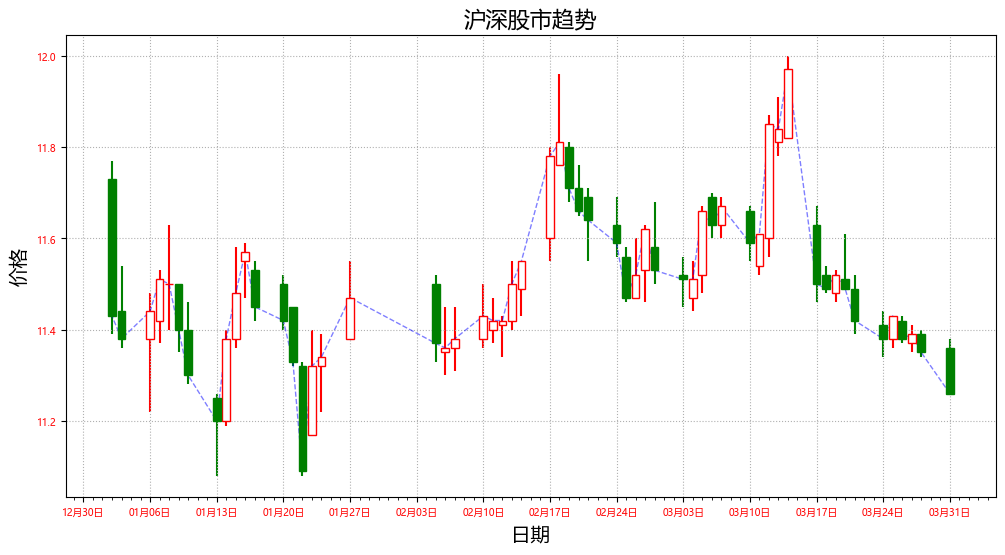

In [9]:
# 绘制收盘价折线图
plt.rcParams["font.family"] = ["Microsoft YaHei"]

plt.figure(figsize=(12, 6))
plt.title('沪深股市趋势', fontsize=16)
plt.xlabel('日期', fontsize=14)
plt.ylabel('价格', fontsize=14)
plt.tick_params(labelsize=7, labelcolor="red", labelrotation=0)
plt.grid(linestyle=':')

# 设置x轴刻度定位器
ax = plt.gca()
ax.xaxis.set_major_locator(dt.WeekdayLocator(byweekday=dt.MO))
# ax.xaxis.set_major_formatter(dt.DateFormatter('%Y年%m月%d日'))
ax.xaxis.set_major_formatter(dt.DateFormatter('%m月%d日'))
ax.xaxis.set_minor_locator(dt.DayLocator())

# 绘制曲线
plt.plot("trade_date", "close", alpha=0.5, color='blue', linewidth=1, linestyle='--', data=df)


# 控制实体与影线的颜色
rise = df["close"] >= df["open"]   # 股票的升降
color = np.array(['white' if x else 'green' for x in rise])  # 条形图颜色 
ecolor = np.array(['red' if x else 'green' for x in rise])  # 条形图边界颜色

# 绘制实体
plt.bar("trade_date", df["close"] - df["open"], 0.8, "open",  color=color, edgecolor=ecolor, zorder=3, data=df)

# 绘制影线
plt.vlines("trade_date", "low", "high", color=ecolor, zorder=1, data=df)

# plt.gcf().autofmt_xdate()  # 自动格式化
plt.show()

---